In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# loading dataset
df = pd.read_csv("students.csv")

# checking data
print(df.head())

# shape and types
print(df.shape)
print(df.dtypes)

# summary
print(df.describe())

# pass/fail count
print(df['passed'].value_counts())

# subjects list
subject_cols = ['math','science','english','history','pe']

# averages
print("Pass avg:")
print(df[df['passed']==1][subject_cols].mean())

print("Fail avg:")
print(df[df['passed']==0][subject_cols].mean())

# top student
df['avg'] = df[subject_cols].mean(axis=1)
top = df.loc[df['avg'].idxmax()]
print("Top student:", top['name'])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.000000  

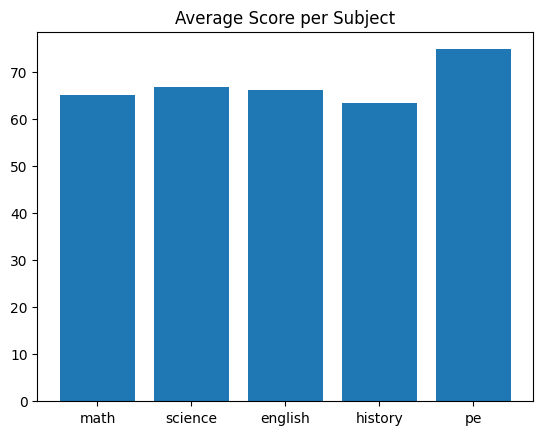

In [3]:
import matplotlib.pyplot as plt

df['avg_score'] = df[subject_cols].mean(axis=1)

# bar chart
avg = df[subject_cols].mean()
plt.bar(avg.index, avg.values)
plt.title("Average Score per Subject")
plt.savefig("plot1_bar.png")
plt.show()

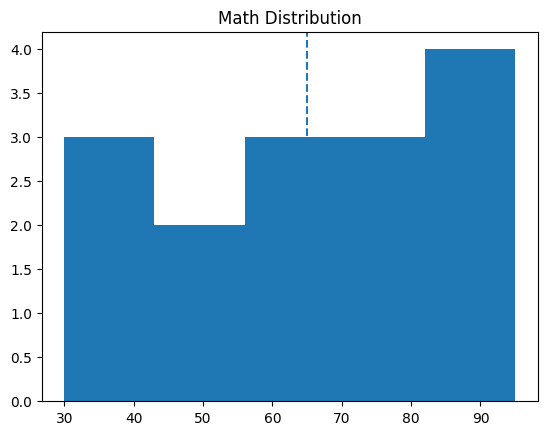

In [4]:
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Distribution")
plt.savefig("plot2_hist.png")
plt.show()

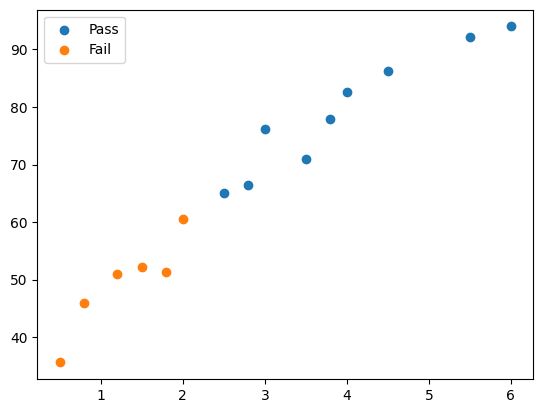

In [5]:
p = df[df['passed']==1]
f = df[df['passed']==0]

plt.scatter(p['study_hours_per_day'], p['avg_score'], label='Pass')
plt.scatter(f['study_hours_per_day'], f['avg_score'], label='Fail')
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20032\1623633568.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([p['attendance_pct'], f['attendance_pct']], labels=['Pass','Fail'])


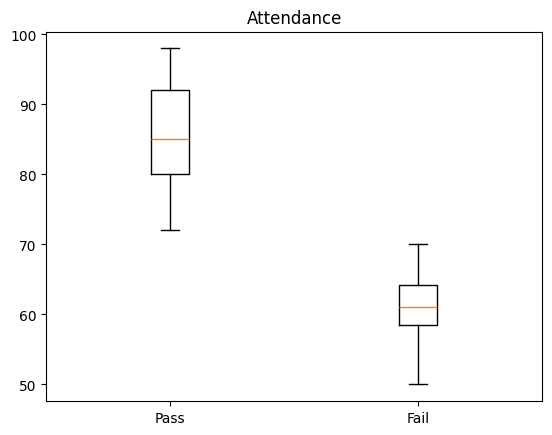

In [6]:
plt.boxplot([p['attendance_pct'], f['attendance_pct']], labels=['Pass','Fail'])
plt.title("Attendance")
plt.savefig("plot4_box.png")
plt.show()

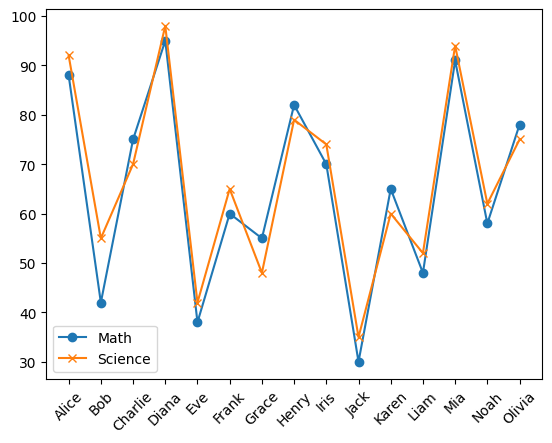

In [7]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

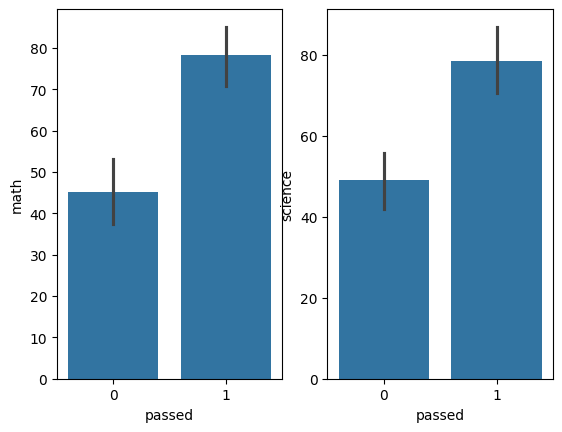

In [8]:
import seaborn as sns

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')

plt.savefig("plot6_seaborn_bar.png")
plt.show()

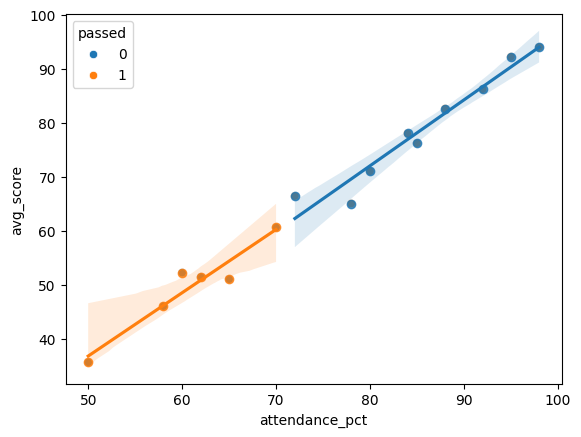

In [9]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
# seaborn was easier for making good looking charts quickly
# matplotlib needed more manual work but gives full control

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

print("Train acc:", model.score(X_train,y_train))
print("Test acc:", model.score(X_test,y_test))



Train acc: 1.0
Test acc: 1.0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

test_index = X_test.index   

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
pred = model.predict(X_test)

for i, idx in enumerate(test_index):
    name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    predicted = pred[i]

    if actual == predicted:
        result = "correct"
    else:
        result = "wrong"

    print(name, actual, predicted, result)

Jack 0 0 correct
Liam 0 0 correct
Alice 1 1 correct
